Vivino Analysis:
Discovery phase

In [1]:
## imports

import sqlite3
from pathlib import Path


In [2]:
# Connecting to db and loading the 
#db_path = "../data/vivino.db"
%load_ext sql
%sql sqlite:///../data/vivino.db

## Usefull info lines: 
# %sql?
# %sqlcmd tables
# %sqlcmd columns -t countries

Tip: You may define configurations in /Users/jkzmr/Developer/becode/vivinodb/pyproject.toml or /Users/jkzmr/.jupysql/config.

Did not find user configurations in /Users/jkzmr/Developer/becode/vivinodb/pyproject.toml.

Connecting to 'sqlite:///../data/vivino.db'

In [3]:

%%sql 
SELECT *
FROM countries
LIMIT 10;

Running query in 'sqlite:///../data/vivino.db'

code,name,regions_count,users_count,wines_count,wineries_count
it,Italie,563,4270717,274658,42399
fr,France,1306,5973301,422503,67553
us,États-Unis,362,12273684,204060,28145
es,Espagne,152,2264396,102662,18026
pt,Portugal,93,1123535,39847,5834
au,Australie,120,1022965,90954,13946
hu,Hongrie,29,102235,16605,1923
za,Afrique du Sud,112,269649,30857,4227
de,Allemagne,236,2549989,164533,13643
cl,Chili,41,326757,41191,5785


Counting :
- Top 10 rated wines with > 200 ratings



%%sql
SELECT * --name, ratings_average, ratings_count
FROM wines
WHERE ratings_count > 200
ORDER BY ratings_average DESC
LIMIT 10


- 41 wines have a rating of 4.7
%%sql
SELECT COUNT(distinct(id))
FROM wines
WHERE ratings_average = 4.7
ORDER BY ratings_average DESC
LIMIT 10



Average Ratings and how many wines have them:

In [44]:
%%sql 
SELECT ratings_average, COUNT(distinct(id)) AS count
FROM wines
GROUP BY ratings_average
ORDER BY ratings_average DESC


Running query in 'sqlite:///../data/vivino.db'

ratings_average,count
4.8,6
4.7,41
4.6,140
4.5,259
4.4,372
4.3,165
4.2,33
4.1,4


Average ratings:

<Axes: title={'center': "'ratings_average' from 'wines'"}, xlabel='ratings_average', ylabel='Count'>

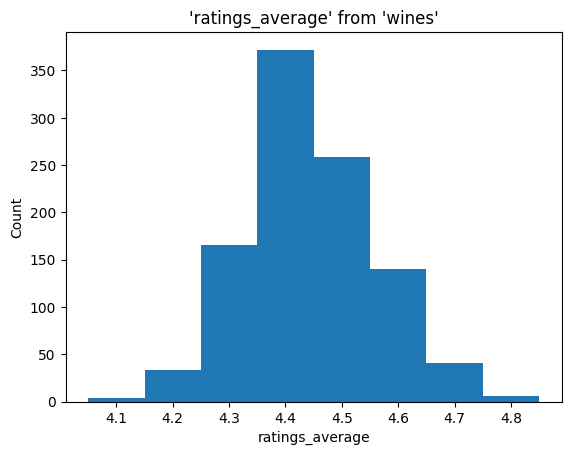

In [6]:
%sqlplot histogram --table wines --column ratings_average --bins 8


Average price by rating:

In [43]:
%%sql --save avg_price_by_rating
SELECT  ratings_average,  AVG(price_euros)
FROM vintages
WHERE ratings_average > 4.0
GROUP BY ratings_average
ORDER BY ratings_average ASC
LIMIT 10

Running query in 'sqlite:///../data/vivino.db'

ratings_average,AVG(price_euros)
4.4,180.611325
4.5,393.61355513307984
4.6,698.740625
4.7,1443.0347142857142
4.8,1861.7382352941177
4.9,1183.775


In [17]:
%%sql --save vint_count
SELECT price_euros, bottle_volume_ml, ratings_average, ratings_count
FROM vintages
WHERE ratings_average > 4.0 AND ratings_count > 100
ORDER BY ratings_average DESC


Running query in 'sqlite:///../data/vivino.db'

price_euros,bottle_volume_ml,ratings_average,ratings_count
1900.0,750,4.8,1000
3522.5,750,4.8,235
2882.5,750,4.8,1004
1921.25,750,4.8,104
3096.25,750,4.8,333
6300.0,750,4.8,1190
2455.0,750,4.8,330
555.0,750,4.8,208
1686.25,750,4.8,920
425.0,750,4.8,444


<Axes: title={'center': "'ratings_average' from 'vint_count'"}, xlabel='ratings_average', ylabel='Count'>

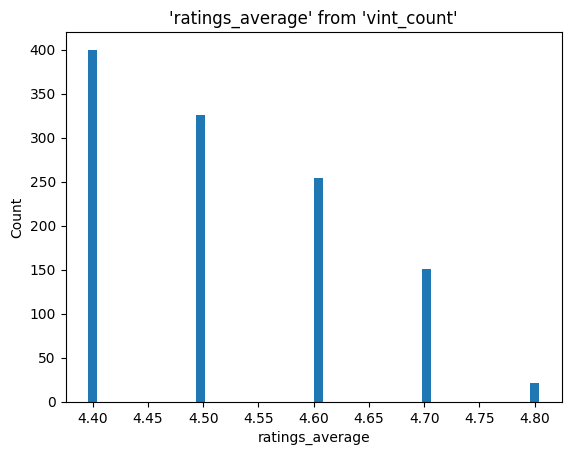

In [8]:
%sqlplot hist --table vint_count --column ratings_average --bins=5

Average price of vintages by rating

In [11]:
%%sql
SELECT AVG(price_euros), ratings_average
FROM vintages
WHERE ratings_average > 4
GROUP BY ratings_average
ORDER BY ratings_average DESC



Running query in 'sqlite:///../data/vivino.db'

AVG(price_euros),ratings_average
1183.775,4.9
1861.7382352941177,4.8
1443.0347142857142,4.7
698.740625,4.6
393.61355513307984,4.5
180.611325,4.4


Highlight 10 wines:
For prices, careful with discounts

What wines should we highlight?
- Very good wines : > 4.6 average score
- not very well known : under 500 user ratings, but above 100. 
- Have a mix of red and whites
- Variety of countries

Selection: 10 bottles for every budget: (+1 for dreaming...)
5X Great deal: 4.4 (2 white, 3 reds)
3X Excellent: 4.5
2X Amazing: 4.6
1X Luxury : 4.7 and up


**WINNERS SO FAR**

| Wine ID | Vintage ID | Rating | Country      | Region                | Price           | RED/WHITE | Name                                                     |
|---------|------------|--------|--------------|-----------------------|-----------------|-----------|----------------------------------------------------------|
| 1129440 | 160148272  | 4.4    | Italy        | Primitivo di Manduria | 23(re-adjusted) | Red       | Luccarelli Old Vines Primitivo di Manduria 2019          |
| 3783366 | 152008500  | 4.4    | Moldavie     | Moldova               | 46.77 (1.5l)    | White     | Gitana Saperavi 2017                                     |
| 16504   | 159319855  | 4.4    | Mendoza      | Argentina             | 25.99           | Red       | Rutini Malbec 2019                                       |
| 2246136 | 156124899  | 4.4    | Maipo Valley | Chili                 | 29.95           | White     | El Principal Memorias 2018                               |
| 5364329 | 163053458  | 4.4    | Abruzzo      | Italy                 | 23.9            | Red       | Farnese Cinque Autoctoni Collection Limited Release 2020 |
|         |            | 4.5    |              |                       |                 |           |                                                          |





Joining some tables: 
I have my doubts that these are different wine id is different, and but vintage is different, but bodega can be the same
I should include some different tasting notes.
i need to adjust price by volume

**REMARKS**
12 wines have a discount; not a big deal.

In [ ]:
%%sql
SELECT *
FROM vintages
JOIN wines on wines.id = vintages.wine_id
WHERE vintages.price_discount_percentage > 16

ORDER BY price_discount_percentage DESC
LIMIT 100

Trying to see the wines that appear more than once:


In [ ]:
%%sql
SELECT wines.id, wines.name, vintages.wine_id, count(wines.id)
FROM wines
JOIN vintages on wines.id = vintages.wine_id
GROUP BY wines.id
HAVING count(wines.id) >=2 -- AND count(wines.id) < 7 
ORDER BY count(wines.id) DESC
LIMIT 10

Running query in 'sqlite:///../data/vivino.db'

id,name,wine_id,count(wines.id)
22447,Bolgheri Superiore,22447,26
5078,Sassicaia,5078,25
2446729,Toscana,2446729,24
3908,Pauillac (Premier Grand Cru Classé),3908,19
1558589,Brunello di Montalcino,1558589,17
82698,Brunello di Montalcino Riserva,82698,16
66104,Barbaresco,66104,16
1652,Tignanello,1652,16
1152755,Pessac-Léognan (Premier Grand Cru Classé),1152755,15
1127795,Château Margaux (Premier Grand Cru Classé),1127795,14


Shows the 

In [207]:
%%sql
SELECT wine_id, vintages.name, vintages.id AS vintage_id, regions.name AS region_name, countries.name AS country_name, vintages.ratings_average, vintages.ratings_count, vintages.price_euros, price_discounted_from,  bottle_volume_ml, wines.tannin, round((price_euros / bottle_volume_ml)*750) AS adjusted_price -- bottle_volume_ml, price_euros, 
FROM  vintages
JOIN wines ON wines.id = vintages.wine_id
JOIN regions ON regions.id =  wines.region_id
JOIN countries ON countries.code = regions.country_code
--JOIN wineries ON wines.winery_id = wineries.id   --  wineries.name AS winery_name
WHERE vintages.ratings_average > 3. AND vintages.ratings_count > 200 --AND wines.tannin IS NULL --AND vintages.ratings_count < 500 -- 
ORDER BY adjusted_price ASC





Running query in 'sqlite:///../data/vivino.db'

wine_id,name,vintage_id,region_name,country_name,ratings_average,ratings_count,price_euros,price_discounted_from,bottle_volume_ml,tannin,adjusted_price
1129440,Luccarelli Old Vines Primitivo di Manduria 2019,160148272,Primitivo di Manduria,Italie,4.4,274,20.95,22.95,750,2.3452597,21.0
3783366,Gitana Saperavi 2017,152008500,Moldova,Moldavie,4.4,788,46.77,None,1500,None,23.0
6741558,Vigneti del Salento Vigne Vecchie Gold Series Leggenda Primitivo di Manduria 2019,160094800,Primitivo di Manduria,Italie,4.5,424,23.95,30.0,750,2.3039157,24.0
5364329,Farnese Cinque Autoctoni Collection Limited Release 2020,163053458,Abruzzo,Italie,4.4,255,23.9,None,750,2.8115416,24.0
11890,San Marzano 60 Sessantanni Old Vines Primitivo di Manduria 2018,156098276,Primitivo di Manduria,Italie,4.4,1748,24.75,None,750,2.2129438,25.0
16504,Rutini Malbec 2019,159319855,Mendoza,Argentine,4.4,2567,25.99,None,750,2.6998742,26.0
1627830,Waterford Estate Kevin Arnold Shiraz 2016,146295008,Stellenbosch,Afrique du Sud,4.4,466,26.9,None,750,3.0410163,27.0
6331780,Guerrieri Guerriero della Terra 2019,160549459,Marche,Italie,4.4,1803,27.4,None,750,2.6898563,27.0
5509286,Luccarelli Il Bacca Old Vine Primitivo di Manduria 2019,159429226,Primitivo di Manduria,Italie,4.4,276,27.75,None,750,2.3699353,28.0
1131353,Von Siebenthal Carabantes Syrah 2020,162987799,Aconcagua Valley,Chili,4.4,227,27.98,None,750,2.9519954,28.0


cheapest wines

In [205]:
%%sql
SELECT wine_id, vintages.name, vintages.id AS vintage_id, regions.name AS region_name, countries.name AS country_name, vintages.ratings_average, vintages.ratings_count, vintages.price_euros, price_discounted_from,  bottle_volume_ml, wines.tannin, round((price_euros / bottle_volume_ml)*750) AS adjusted_price -- bottle_volume_ml, price_euros, 
FROM  vintages
JOIN wines ON wines.id = vintages.wine_id
JOIN regions ON regions.id =  wines.region_id
JOIN countries ON countries.code = regions.country_code
--JOIN wineries ON wines.winery_id = wineries.id   --  wineries.name AS winery_name
WHERE vintages.ratings_average > 3. AND vintages.ratings_count > 100 --AND wines.tannin IS NULL --AND vintages.ratings_count < 500 -- 
ORDER BY adjusted_price ASC

Running query in 'sqlite:///../data/vivino.db'

wine_id,name,vintage_id,region_name,country_name,ratings_average,ratings_count,price_euros,price_discounted_from,bottle_volume_ml,tannin,adjusted_price
1129440,Luccarelli Old Vines Primitivo di Manduria 2019,160148272,Primitivo di Manduria,Italie,4.4,274,20.95,22.95,750,2.3452597,21.0
3783366,Gitana Saperavi 2017,152008500,Moldova,Moldavie,4.4,788,46.77,None,1500,None,23.0
6741558,Vigneti del Salento Vigne Vecchie Gold Series Leggenda Primitivo di Manduria 2019,160094800,Primitivo di Manduria,Italie,4.5,424,23.95,30.0,750,2.3039157,24.0
5364329,Farnese Cinque Autoctoni Collection Limited Release 2020,163053458,Abruzzo,Italie,4.4,255,23.9,None,750,2.8115416,24.0
11890,San Marzano 60 Sessantanni Old Vines Primitivo di Manduria 2018,156098276,Primitivo di Manduria,Italie,4.4,1748,24.75,None,750,2.2129438,25.0
1145499,Elio Perrone Mongovone Barbera d'Asti Superiore 2020,165538727,Barbera d'Asti,Italie,4.4,191,32.95,None,1000,2.233243,25.0
16504,Rutini Malbec 2019,159319855,Mendoza,Argentine,4.4,2567,25.99,None,750,2.6998742,26.0
6331780,Guerrieri Guerriero della Terra 2020,165224957,Marche,Italie,4.4,182,25.95,None,750,2.6898563,26.0
1627830,Waterford Estate Kevin Arnold Shiraz 2016,146295008,Stellenbosch,Afrique du Sud,4.4,466,26.9,None,750,3.0410163,27.0
6331780,Guerrieri Guerriero della Terra 2019,160549459,Marche,Italie,4.4,1803,27.4,None,750,2.6898563,27.0
